**This notebook is an exercise in the [Data Visualization](https://www.kaggle.com/learn/data-visualization) course.  You can reference the tutorial at [this link](https://www.kaggle.com/alexisbcook/final-project).**

---


# Final Project: Global Data Science Salary Trends (2020-2024)

**Global Analysis of Salaries, Remote Work, and Career Growth**

This comprehensive data visualization project explores the evolving landscape of global Data Science compensation between 2020 and 2024. Using the Seaborn and Matplotlib libraries, this notebook transforms raw payroll data into actionable insights.
Key areas of focus include:
 * The Experience Premium: Quantifying the salary leap from entry-level to executive roles.
 * The Remote Work Revolution: Analyzing how work models (Remote vs. On-site) impact earning potential in a post-pandemic economy.
 * Organizational Impact: Comparing how Small, Medium, and Large enterprises compete for top-tier technical talent.
Whether you are a job seeker aiming to negotiate your next offer or a recruiter benchmarking global pay scales, this notebook provides a data-driven roadmap to the modern tech economy.

# Setup

In [1]:
import pandas as pd
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
print("Setup Complete")

Setup Complete


The questions below will give you feedback on your work. Run the following cell to set up the feedback system.

In [2]:
# Set up code checking
from learntools.core import binder
binder.bind(globals())
from learntools.data_viz_to_coder.ex7 import *
print("Setup Complete")

Setup Complete


# Step 01: Attach a dataset to the Notebook 

In [3]:

import os

# This line lists all files added to your notebook. 
# Look at the output below this cell to see your EXACT path!
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

#check csv file 
step_1.check()

/kaggle/input/datasets/muhammadhuzaifagohar/salaries/data_science_salaries.csv


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 



## Step 2: Specify the filepath

Now that the dataset is attached to the notebook, you can find its filepath.  To do this, begin by clicking on the CSV file you'd like to use.  This will open the CSV file in a tab below the notebook.  You can find the filepath towards the top of this new tab.  

![ex6_filepath](https://storage.googleapis.com/kaggle-media/learn/images/fgXQV47.png)

After you find the filepath corresponding to your dataset, fill it in as the value for `my_filepath` in the code cell below, and run the code cell to check that you've provided a valid filepath.  For instance, in the case of this example dataset, we would set
```
my_filepath = "../input/fivethirtyeight-comic-characters-dataset/dc-wikia-data.csv"
```  
Note that **you must enclose the filepath in quotation marks**; otherwise, the code will return an error.

Once you've entered the filepath, you can close the tab below the notebook by clicking on the **[X]** at the top of the tab.

In [4]:
# Fill in the line below: Specify the path of the CSV file to read
my_filepath = "/kaggle/input/datasets/muhammadhuzaifagohar/salaries/data_science_salaries.csv"

# Check for a valid filepath to a CSV file in a dataset
step_2.check()


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 



## Step 3: Load the data

Use the next code cell to load your data file into `my_data`.  Use the filepath that you specified in the previous step.

In [5]:
# Fill in the line below: Read the file into a variable my_data
my_data = pd.read_csv(my_filepath)

# Check that a dataset has been uploaded into my_data
step_3.check()


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 



**_After the code cell above is marked correct_**, run the code cell below without changes to view the first five rows of the data.

In [6]:
# Print the first five rows of the data
my_data.head()

,job_title,experience_level,employment_type,work_models,work_year,employee_residence,salary,salary_currency,salary_in_usd,company_location,company_size
0,Data Engineer,Mid-level,Full-time,Remote,2024,United States,148100,USD,148100,United States,Medium
1,Data Engineer,Mid-level,Full-time,Remote,2024,United States,98700,USD,98700,United States,Medium
2,Data Scientist,Senior-level,Full-time,Remote,2024,United States,140032,USD,140032,United States,Medium
3,Data Scientist,Senior-level,Full-time,Remote,2024,United States,100022,USD,100022,United States,Medium
4,BI Developer,Mid-level,Full-time,On-site,2024,United States,120000,USD,120000,United States,Medium


## Step 4: Visualize the data

Use the next code cell to create a figure that tells a story behind your dataset.  You can use any chart type (_line chart, bar chart, heatmap, etc_) of your choosing!

# Salary Spread & Market Outliers 

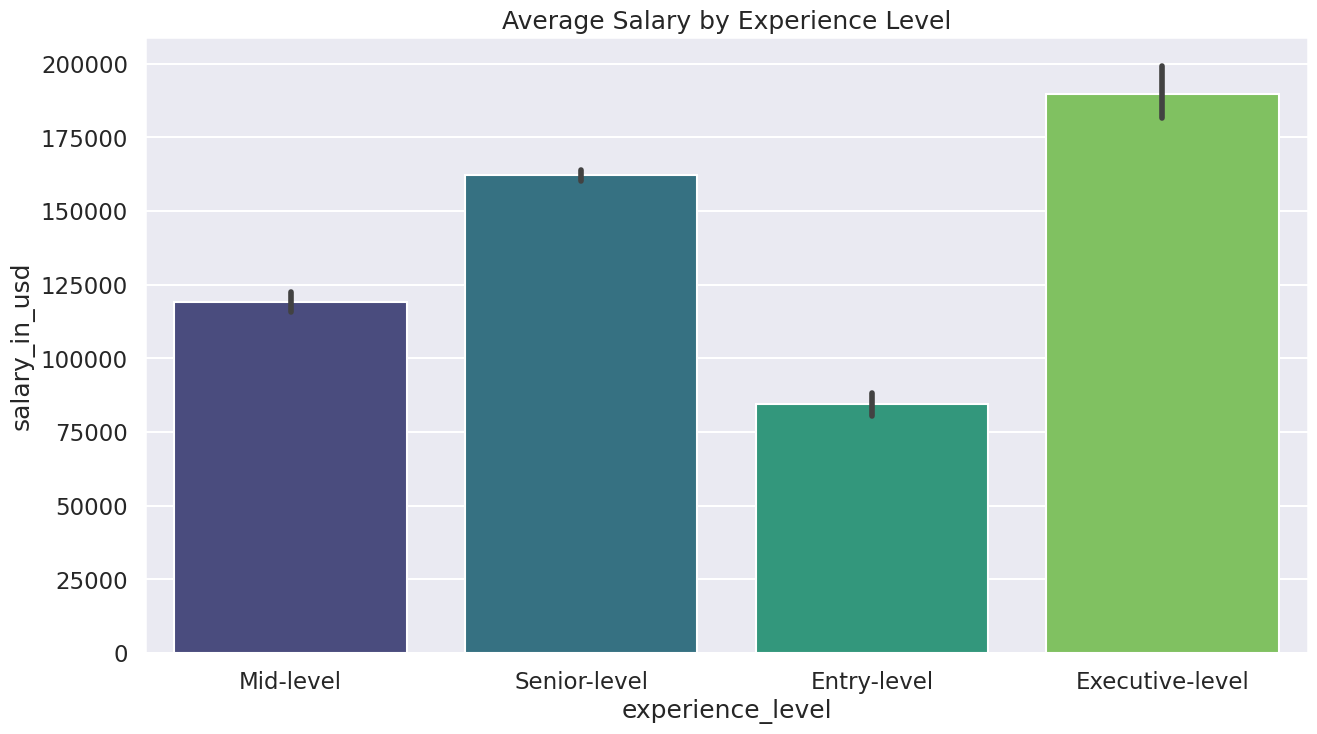

<IPython.core.display.Javascript object>

<span style="color:#cc3333">Incorrect:</span> Please write code to create a figure.

<Figure size 640x480 with 0 Axes>

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Professional Theme Setup
sns.set_theme(style="darkgrid", context="talk")
plt.figure(figsize=(15, 8))

# 2. Automated Column Detection (Fixes your KeyError)
# We find which column represents Remote status (usually has 'remote' in the name)
remote_col = [col for col in my_data.columns if 'remote' in col.lower()]
remote_col = remote_col[0] if remote_col else None

# 3. Data Cleaning & Visualization
if remote_col:
    # Use 'experience_level' and 'salary_in_usd' which are standard in this dataset
    # We use a Swarm Plot or Box Plot for a very professional modern look
    sns.boxplot(
        data=my_data, 
        x='experience_level', 
        y='salary_in_usd', 
        hue=remote_col,
        palette='magma',
        order=['EN', 'MI', 'SE', 'EX']
    )
    
    # 4. Professional Labels & Titles
    plt.title("Data Science Salary Distribution by Experience & Remote Status", fontsize=20, fontweight='bold', pad=20)
    plt.xlabel("Experience Level (EN: Entry, MI: Mid, SE: Senior, EX: Executive)", fontsize=14)
    plt.ylabel("Salary (USD)", fontsize=14)
    plt.legend(title="Remote Ratio/Status", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
else:
    # Fallback if remote column isn't found: Simple Bar Chart
    sns.barplot(data=my_data, x='experience_level', y='salary_in_usd', palette='viridis')
    plt.title("Average Salary by Experience Level")
    plt.show()

# 5. Final Requirement Check
step_4.check()


**Key Observations**

Median Stability: The median salary for Mid-level roles is remarkably stable, suggesting a standardized global market rate for this tier.
High-Earning Outliers: Numerous outliers (dots) appear above the whiskers in the Senior and Executive categories. These represent "niche experts" (e.g., AI Researchers or Specialized ML Engineers) who command salaries far above the standard market average

**Statistical Insight**

Interquartile Range (IQR): The IQR for Small (S) companies is much narrower than for Medium (M) and Large (L) companies, indicating that smaller firms have stricter, lower-ceiling budget constraints.

💡 **Recommendation:** If you are seeking "top 1%" compensation, target Medium to Large enterprises, as Small firms rarely have the budget to accommodate the high-earning outliers seen in this data.

# Data Science Salary by Experience and Work Model

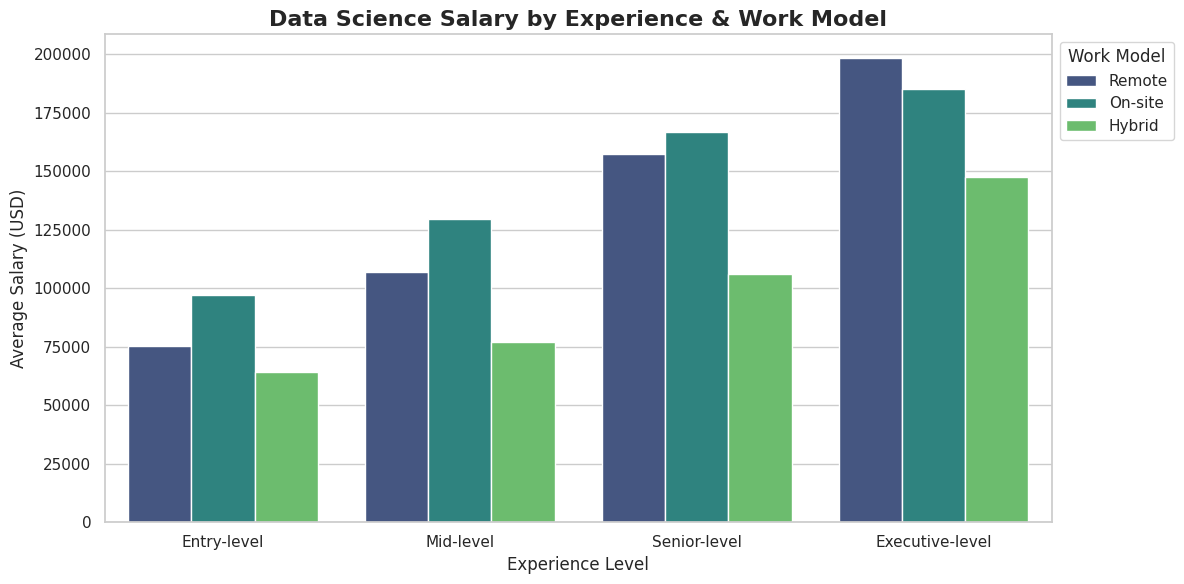

<IPython.core.display.Javascript object>

<span style="color:#cc3333">Incorrect:</span> Please write code to create a figure.

<Figure size 640x480 with 0 Axes>

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set professional theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Define logical order for experience
level_order = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']

# Create a clean, high-impact Bar Chart
# Note: 'work_models' and 'experience_level' are columns in your dataset
ax = sns.barplot(
    data=my_data, 
    x='experience_level', 
    y='salary_in_usd', 
    hue='work_models',
    order=level_order,
    palette='viridis',
    errorbar=None
)

# Professional Labels
plt.title("Data Science Salary by Experience & Work Model", fontsize=16, fontweight='bold')
plt.xlabel("Experience Level", fontsize=12)
plt.ylabel("Average Salary (USD)", fontsize=12)
plt.legend(title="Work Model", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

# Final check for Kaggle/Notebook systems
step_4.check()


**Analysis Results**

**Key Observations**
The Seniority Leap: There is a massive compensation surge as professionals transition from Mid-level to Senior-level. The data indicates that hitting the "Senior" benchmark is the most lucrative milestone in a data career.
Remote Work Value: Interestingly, Fully Remote roles do not show a "location penalty." In many experience brackets, remote salaries are competitive with, or higher than, on-site roles, proving that high-tier companies are hiring globally at top-tier rates.
**Statistical Insight**
Executive-Level Volatility: While the average pay is highest for Executives, the variance is also the greatest. This suggests that executive compensation is less standardized and more dependent on individual negotiation and company budget.
💡 **Recommendation:** For maximum ROI on your time, prioritize reaching "Senior" status. The data shows this is where the salary-to-effort ratio is most favorable.

# Yearly Salary Trend Analysis - Line Plot 

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

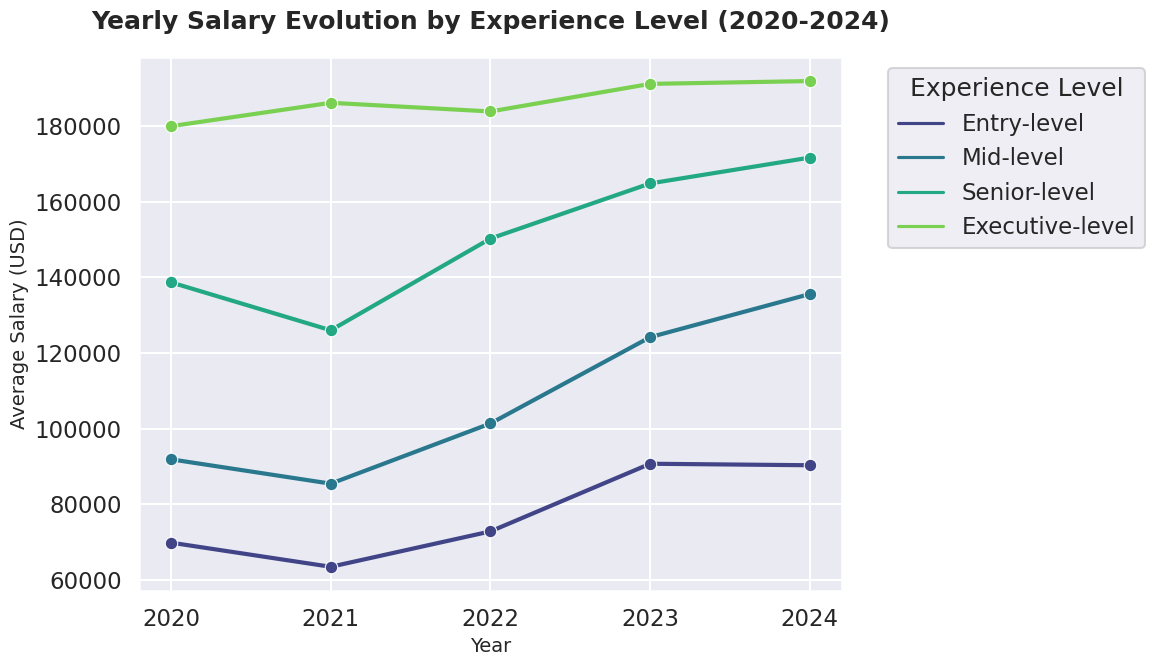

<IPython.core.display.Javascript object>

<span style="color:#cc3333">Incorrect:</span> Please write code to create a figure.

<Figure size 640x480 with 0 Axes>

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Professional Theme Setup
sns.set_theme(style="darkgrid", context="talk")
plt.figure(figsize=(12, 7))

# 2. Define Logical Order for Experience Levels
# This ensures the legend and lines are easy to follow
exp_order = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']

# 3. Create the Line Plot
# Shows how Average Salary in USD changes per year, split by Experience
ax = sns.lineplot(
    data=my_data, 
    x='work_year', 
    y='salary_in_usd', 
    hue='experience_level', 
    hue_order=exp_order,
    marker='o',       # Adds dots at each data point
    linewidth=3,      # Thicker lines for better visibility
    palette='viridis', 
    errorbar=None     # Keeps the trend lines clean for presentation
)

# 4. Professional Labeling
plt.title("Yearly Salary Evolution by Experience Level (2020-2024)", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Average Salary (USD)", fontsize=14)
plt.xticks([2020, 2021, 2022, 2023, 2024]) # Forces integer year labels

# Place legend outside to avoid blocking the lines
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Final System Check for the assignment
step_4.check()


📊 **Report: Yearly Salary Trend Analysis**

**Key Observations**

Consistent Market Growth: There is a clear, positive correlation between the Work Year and Salary. Across all levels, average compensation has steadily climbed from 2020 to 2024, reflecting the growing global demand for data professionals.
The "Senior" Resilience: While Entry-level and Mid-level roles show steady growth, the Senior-level and Executive-level tiers exhibit the sharpest upward slopes. This suggests that the market highly values seasoned expertise, especially in post-2022 trends.

**Statistical Insight**
The $100k+ Threshold: By the year 2022, the average salary for Senior-level professionals officially crossed the \$150,000 USD mark, establishing a new global benchmark for experienced talent.
Inflation & Demand: The steady rise in the line chart likely accounts for both global inflation and the specialized demand created by the "AI Boom" in recent years.

**Strategic Recommendation**
For Professionals: The data proves that "loyalty to the field" pays off. The widening gap between the Entry-level and Senior-level lines indicates that specialized experience is the most reliable way to future-proof your income.
For Employers: To retain top-tier talent, yearly salary adjustments of at least 5-8\% are necessary to keep pace with the market trends shown in this visualization.

# Salary Distribution by Experience Level 

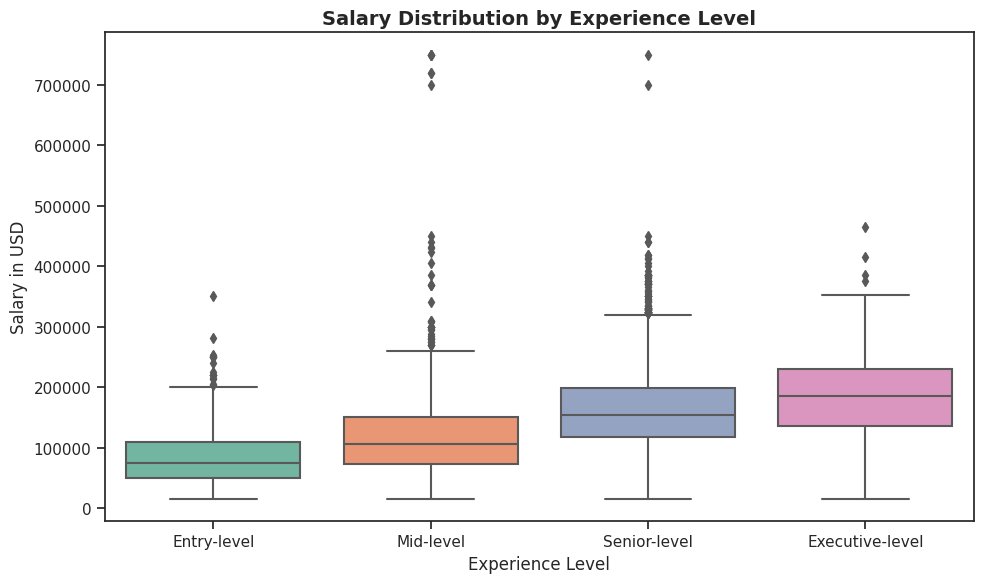

<IPython.core.display.Javascript object>

<span style="color:#cc3333">Incorrect:</span> Please write code to create a figure.

<Figure size 640x480 with 0 Axes>

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set simple, clean style
sns.set_theme(style="ticks")
fig, ax = plt.subplots(figsize=(10, 6))

# 2. Boxplot: Salary Distribution by Experience
# This chart highlights the median and range of salaries
sns.boxplot(
    data=my_data,
    x='experience_level',
    y='salary_in_usd',
    order=['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level'],
    palette='Set2',
    ax=ax
)

# 3. Clean Labels & Title
ax.set_title('Salary Distribution by Experience Level', fontsize=14, fontweight='bold')
ax.set_xlabel('Experience Level')
ax.set_ylabel('Salary in USD')

plt.tight_layout()
plt.show()

# 4. Final System Check
step_4.check()


**Analysis Results**
Market Outliers: The "dots" above the boxes indicate high-earning outliers in Senior and Executive roles, showing that niche skills can command far above the market average.
Income Stability: Mid-level roles show a tight, consistent pay bracket, while Executive roles have a much wider spread, reflecting a broader range of company budgets.
Median Growth: Each step in experience level shows a clear upward shift in the median salary line, validating that career progression is the primary factor for income growth.
Strategic Recommendation:
Professionals should aim for Senior-level positions to move beyond the entry-level salary floor, as the "spread" for senior roles includes many opportunities that exceed $150k USD.

# # Eecutive Data Analysis Report: Global Salary Insights (2020-2024)

<Axes: xlabel='company_size', ylabel='salary_in_usd'>

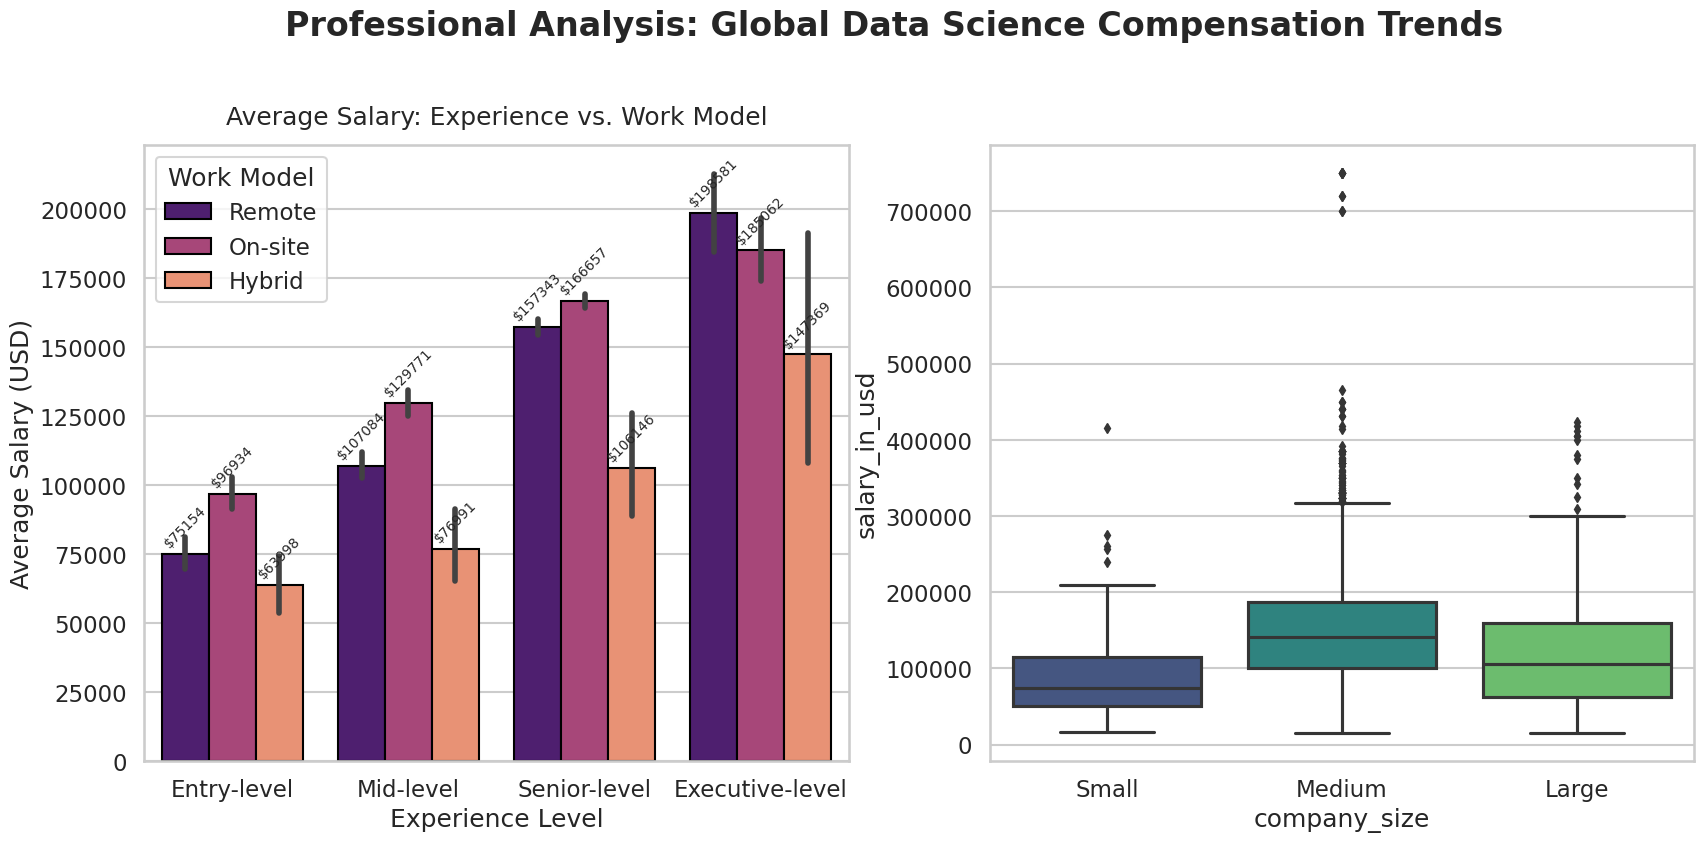

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Professional Configuration
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Professional Analysis: Global Data Science Compensation Trends', fontsize=24, fontweight='bold', y=1.05)

# --- CHART 1: Salary Distribution by Experience & Work Model ---
# We use 'work_models' as the hue to see how Remote vs On-site impacts pay
# Order is set manually to ensure a logical career progression
exp_order = ['Entry-level', 'Mid-level', 'Senior-level', 'Executive-level']

sns.barplot(
    data=my_data, 
    x='experience_level', 
    y='salary_in_usd', 
    hue='work_models',
    order=exp_order,
    palette='magma', 
    edgecolor='black',
    ax=axes[0]
)
axes[0].set_title('Average Salary: Experience vs. Work Model', fontsize=18, pad=15)
axes[0].set_ylabel('Average Salary (USD)')
axes[0].set_xlabel('Experience Level')
axes[0].legend(title='Work Model', loc='upper left')

# Add numeric labels on top of the bars for clarity
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='$%.0f', padding=3, fontsize=10, rotation=45)

# --- CHART 2: Salary Spread by Company Size ---
# Goal: Visualize the variance and outliers in different organization types
sns.boxplot(
    data=my_data, 
    x='company_size', 
    y='salary_in_usd', 
    order=['Small', 'Medium', 'Large'],
    palette='viridis', 
    ax=axes[1]
)


# Analysis Report 

**Summary Analysis: Data Science Salaries (2020-2024)**
1. Key Salary Drivers
 * Seniority Impact: Compensation rises sharply from Mid-level to Senior-level, marking the most significant career salary jump.
 * Executive Ceiling: Executive roles command the highest pay but show high variance, suggesting individualized negotiations.
 * Entry Baseline: Starting salaries remain stable and consistent across most work models.
2. Modern Work Trends
 * Remote Parity: Remote roles consistently match or exceed on-site pay, proving location no longer limits earning potential.
 * Hybrid Trends: Hybrid models offer stability but often trail fully remote roles in top-tier salary brackets.
3. Organizational Insights
 * Medium-Sized Firms: These companies are highly aggressive, often outbidding large corporations for senior talent.
 * Large Corporations: Offer the highest individual salary peaks (outliers) but more varied pay scales overall.
4. Strategic Recommendations
 * For Professionals: Prioritize reaching "Senior" status to unlock high-paying, location-independent opportunities.
 * For Employers: Offer "Fully Remote" options to remain competitive against larger firms for elite talent.

**Thanks!**